### `Building Baseline Statistical Model Benchmark`

`Importing Libraries`

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings('ignore')

`Loading Dataset`

In [70]:
consumption_hourly = pd.read_csv('../dataset/consumption_hourly.csv', na_values='?', index_col='Datetime', parse_dates=True)
consumption_daily = pd.read_csv('../dataset/consumption_daily.csv', na_values='?', index_col='Datetime', parse_dates=True)

In [71]:
consumption_hourly.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,month,year,is_weekend,season,lag_1h,lag_24h,rolling_mean_6h,rolling_mean_24h
Datetime,,,,,,,,,,,,,,,,,
2006-12-17 17:00:00,3.406767,0.166633,234.229833,14.510000,0.0,0.466667,16.816667,17,6,12,2006,1,Winter,3.326033,4.222889,2.564578,2.465140
2006-12-17 18:00:00,3.697100,0.135067,234.372333,15.750000,0.0,0.000000,16.833333,18,6,12,2006,1,Winter,3.406767,3.632200,2.861450,2.467844
2006-12-17 19:00:00,2.908400,0.265167,233.195667,12.516667,0.0,0.516667,16.683333,19,6,12,2006,1,Winter,3.697100,3.400233,3.069389,2.447351
2006-12-17 20:00:00,3.361500,0.271500,236.426500,14.276667,0.0,1.116667,17.116667,20,6,12,2006,1,Winter,2.908400,3.268567,3.280867,2.451224
2006-12-17 21:00:00,3.040767,0.267967,239.104167,12.716667,0.0,1.200000,17.500000,21,6,12,2006,1,Winter,3.361500,3.056467,3.290094,2.450569


In [72]:
consumption_daily.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16,3.053475,0.088187,236.243763,13.082828,0.000000,1.378788,12.439394
2006-12-17,2.354486,0.156949,240.087028,9.999028,1.411806,2.907639,9.264583
2006-12-18,1.530435,0.112356,241.231694,6.421667,0.738194,1.820139,9.734722
2006-12-19,1.157079,0.104821,241.999313,4.926389,0.582639,5.279167,4.303472
2006-12-20,1.545658,0.111804,242.308063,6.467361,0.000000,1.838889,9.765972


In [73]:
# Target: hourly Global Active Power (GAP)
target = consumption_hourly['Global_active_power']

`Using Daily Data for SARIMA, hourly for everything else`

`Splitting Data into Train and Test`

In [74]:
test_days = 90
cutoff = consumption_hourly.index.max() - pd.Timedelta(days=test_days)

train = consumption_hourly[consumption_hourly.index <= cutoff].copy()
test = consumption_hourly[consumption_hourly.index > cutoff].copy()

print(f'Train: {train.index.min()} | {train.index.max()} | {len(train):,} rows')
print(f'Test: {test.index.min()} | {test.index.max()} | {len(test):,} rows')

Train: 2006-12-17 17:00:00 | 2010-08-28 21:00:00 | 32,405 rows
Test: 2010-08-28 22:00:00 | 2010-11-26 21:00:00 | 2,160 rows


In [75]:
train.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,month,year,is_weekend,season,lag_1h,lag_24h,rolling_mean_6h,rolling_mean_24h
Datetime,,,,,,,,,,,,,,,,,
2006-12-17 17:00:00,3.406767,0.166633,234.229833,14.510000,0.0,0.466667,16.816667,17,6,12,2006,1,Winter,3.326033,4.222889,2.564578,2.465140
2006-12-17 18:00:00,3.697100,0.135067,234.372333,15.750000,0.0,0.000000,16.833333,18,6,12,2006,1,Winter,3.406767,3.632200,2.861450,2.467844
2006-12-17 19:00:00,2.908400,0.265167,233.195667,12.516667,0.0,0.516667,16.683333,19,6,12,2006,1,Winter,3.697100,3.400233,3.069389,2.447351
2006-12-17 20:00:00,3.361500,0.271500,236.426500,14.276667,0.0,1.116667,17.116667,20,6,12,2006,1,Winter,2.908400,3.268567,3.280867,2.451224
2006-12-17 21:00:00,3.040767,0.267967,239.104167,12.716667,0.0,1.200000,17.500000,21,6,12,2006,1,Winter,3.361500,3.056467,3.290094,2.450569


In [76]:
test.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,month,year,is_weekend,season,lag_1h,lag_24h,rolling_mean_6h,rolling_mean_24h
Datetime,,,,,,,,,,,,,,,,,
2010-08-28 22:00:00,0.302567,0.131167,243.391167,1.396667,0.0,0.700000,0.666667,22,5,8,2010,1,Summer,0.333400,1.162367,1.014439,1.012176
2010-08-28 23:00:00,0.334433,0.104000,244.383833,1.443333,0.0,0.000000,1.633333,23,5,8,2010,1,Summer,0.302567,0.579067,0.770956,1.001983
2010-08-29 00:00:00,0.691067,0.154933,242.581833,2.960000,0.0,0.700000,1.666667,0,6,8,2010,1,Summer,0.334433,0.456533,0.643844,1.011756
2010-08-29 01:00:00,0.360600,0.110767,241.935833,1.603333,0.0,0.200000,1.666667,1,6,8,2010,1,Summer,0.691067,0.343800,0.467133,1.012456
2010-08-29 02:00:00,0.318633,0.108033,241.196167,1.420000,0.0,0.483333,1.650000,2,6,8,2010,1,Summer,0.360600,0.368367,0.390117,1.010383


`Function Evaluation`

In [77]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f'\n {'='*40}')
    print(f'Model: {name}')
    print(f'MAE : {mae:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'R2: {r2:.4f}')
    print(f'{'='*40}')
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []

`Naive Forcast` (Baseline Zero)

In [78]:
naive_last = pd.Series(
    train[target.name].iloc[-1],
    index=test.index
)

lag_24 = test['lag_24h']

results.append(evaluate('Naive (Last Value)', test[target.name], naive_last))
results.append(evaluate('Naive (Same Hour -1 Day)', test[target.name], lag_24))

lag_24 = test['lag_24h']

results.append(evaluate('Naive (Last Value)', test[target.name], naive_last))
results.append(evaluate('Naive (Same Hour -1 Day)', test[target.name], lag_24))


Model: Naive (Last Value)
MAE : 0.7573
RMSE: 1.0769
R2: -0.8640

Model: Naive (Same Hour -1 Day)
MAE : 0.5699
RMSE: 0.8364
R2: -0.1245

Model: Naive (Last Value)
MAE : 0.7573
RMSE: 1.0769
R2: -0.8640

Model: Naive (Same Hour -1 Day)
MAE : 0.5699
RMSE: 0.8364
R2: -0.1245


`Moving Average Forecast`

In [79]:
# Rolling mean on train, then propagate forward into test
# We compute several window sizes to find the best

for window in [6, 12, 24, 48]:
    # Use rolling mean of last `window` hours from the end of train
    ma_value = train[target.name].rolling(window).mean().iloc[-1]
    ma_pred  = pd.Series(ma_value, index=test.index)
    results.append(evaluate(f"Moving Average ({window}h)", test[target.name], ma_pred))


Model: Moving Average (6h)
MAE : 0.7023
RMSE: 0.8221
R2: -0.0863

Model: Moving Average (12h)
MAE : 0.8093
RMSE: 0.9374
R2: -0.4124

Model: Moving Average (24h)
MAE : 0.6482
RMSE: 0.7890
R2: -0.0006

Model: Moving Average (48h)
MAE : 0.6823
RMSE: 0.8038
R2: -0.0386


`Linear Regression`

In [80]:
# Features for linear regression
features = [
    'hour', 'day_of_week', 'month', 'is_weekend',
    'lag_1h', 'lag_24h',
    'rolling_mean_6h', 'rolling_mean_24h'
]

X_train = train[features]
y_train = train[target.name]
X_test  = test[features]
y_test  = test[target.name]

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

results.append(evaluate("Linear Regression", y_test, lr_pred))

# Feature importance (coefficients)
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nLinear Regression Coefficients:")
print(coef_df.to_string(index=False))


Model: Linear Regression
MAE : 0.4022
RMSE: 0.5605
R2: 0.4950

Linear Regression Coefficients:
         Feature  Coefficient
          lag_1h     0.512639
 rolling_mean_6h     0.181735
         lag_24h     0.170976
rolling_mean_24h     0.079273
      is_weekend     0.024022
            hour     0.006961
     day_of_week     0.004221
           month    -0.000316


`SARIMA`

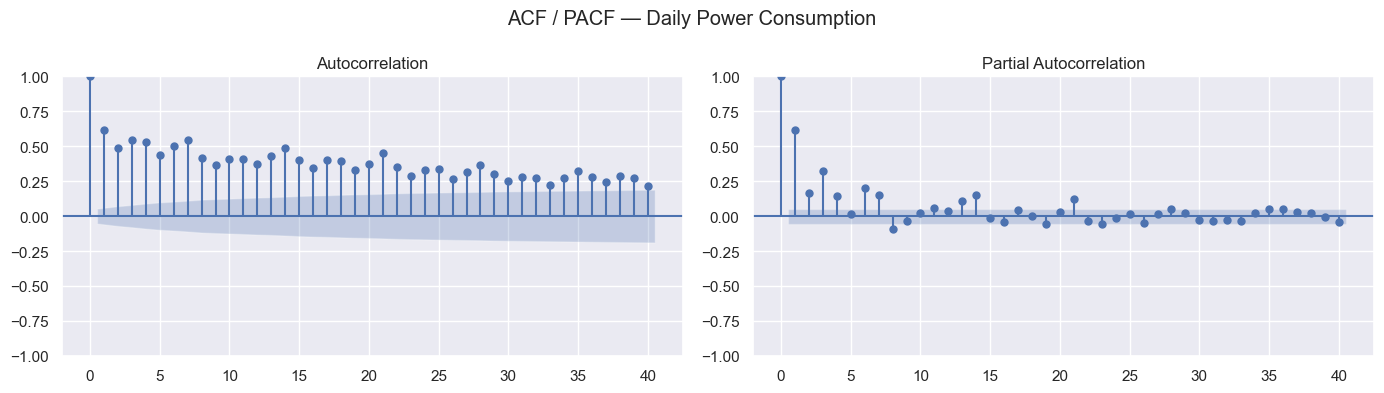

                                     SARIMAX Results                                     
Dep. Variable:               Global_active_power   No. Observations:                 1351
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                -215.444
Date:                           Tue, 02 Jun 2026   AIC                            440.888
Time:                                   13:29:19   BIC                            466.868
Sample:                               12-17-2006   HQIC                           450.624
                                    - 08-28-2010                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2643      0.025     10.442      0.000       0.215       0.314
ma.L1         -0.8670      0.014    -60.326

In [81]:
# SARIMA works best on daily data (manageable size on CPU)
consumption_daily_target = consumption_hourly[target.name].resample('d').mean()

train_sarima = consumption_daily_target[consumption_daily_target.index <= cutoff]
test_sarima  = consumption_daily_target[consumption_daily_target.index >  cutoff]

# Quick ACF/PACF check to validate parameters
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_sarima,  lags=40, ax=axes[0])
plot_pacf(train_sarima, lags=40, ax=axes[1])
plt.suptitle("ACF / PACF — Daily Power Consumption")
plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=150)
plt.show()

# SARIMA(1,1,1)(1,1,1,7) — weekly seasonality, CPU-safe order
sarima_model = SARIMAX(
    train_sarima,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

# Forecast for test period
sarima_pred = sarima_fit.forecast(steps=len(test_sarima))
results.append(evaluate("SARIMA(1,1,1)(1,1,1,7)", test_sarima, sarima_pred))

`Comparing all Baseline`


 Phase 2 — Baseline Leaderboard
                   Model      MAE     RMSE        R2
  SARIMA(1,1,1)(1,1,1,7) 0.388951 0.457277 -1.246071
       Linear Regression 0.402222 0.560524  0.494996
    Moving Average (24h) 0.648176 0.788982 -0.000554
    Moving Average (48h) 0.682256 0.803837 -0.038585
     Moving Average (6h) 0.702257 0.822080 -0.086261
Naive (Same Hour -1 Day) 0.569855 0.836434 -0.124524
Naive (Same Hour -1 Day) 0.569855 0.836434 -0.124524
    Moving Average (12h) 0.809330 0.937387 -0.412354
      Naive (Last Value) 0.757318 1.076889 -0.864007
      Naive (Last Value) 0.757318 1.076889 -0.864007


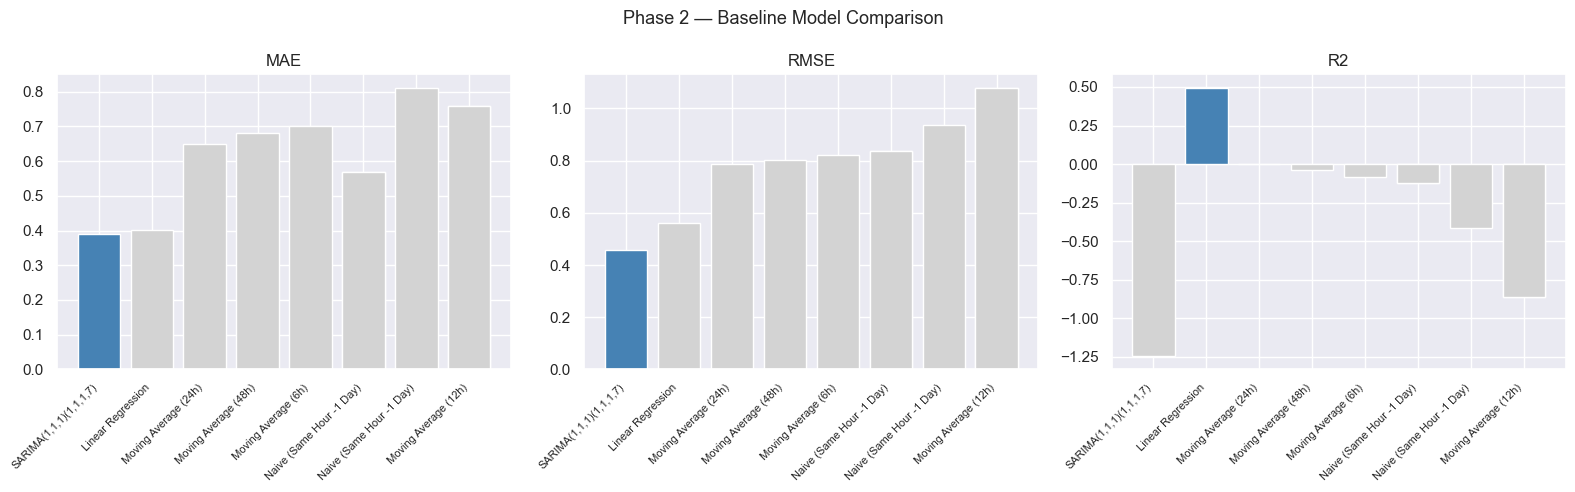

In [82]:
consumption_results = pd.DataFrame(results).sort_values('RMSE')

print("\n Phase 2 — Baseline Leaderboard")
print(consumption_results.to_string(index=False))

# Plot leaderboard
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    colors = ['steelblue' if v == consumption_results[metric].min() else 'lightgray'
              for v in consumption_results[metric]]
    if metric == 'R2':
        colors = ['steelblue' if v == consumption_results[metric].max() else 'lightgray'
                  for v in consumption_results[metric]]
    axes[list('MAE RMSE R2'.split()).index(metric)].bar(
        consumption_results['Model'], consumption_results[metric], color=colors
    )
    ax.set_title(metric)
    ax.set_xticklabels(consumption_results['Model'], rotation=45, ha='right', fontsize=8)

plt.suptitle("Phase 2 — Baseline Model Comparison", fontsize=13)
plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=150)
plt.show()

`Visualizing Best Baseline vs Actual`

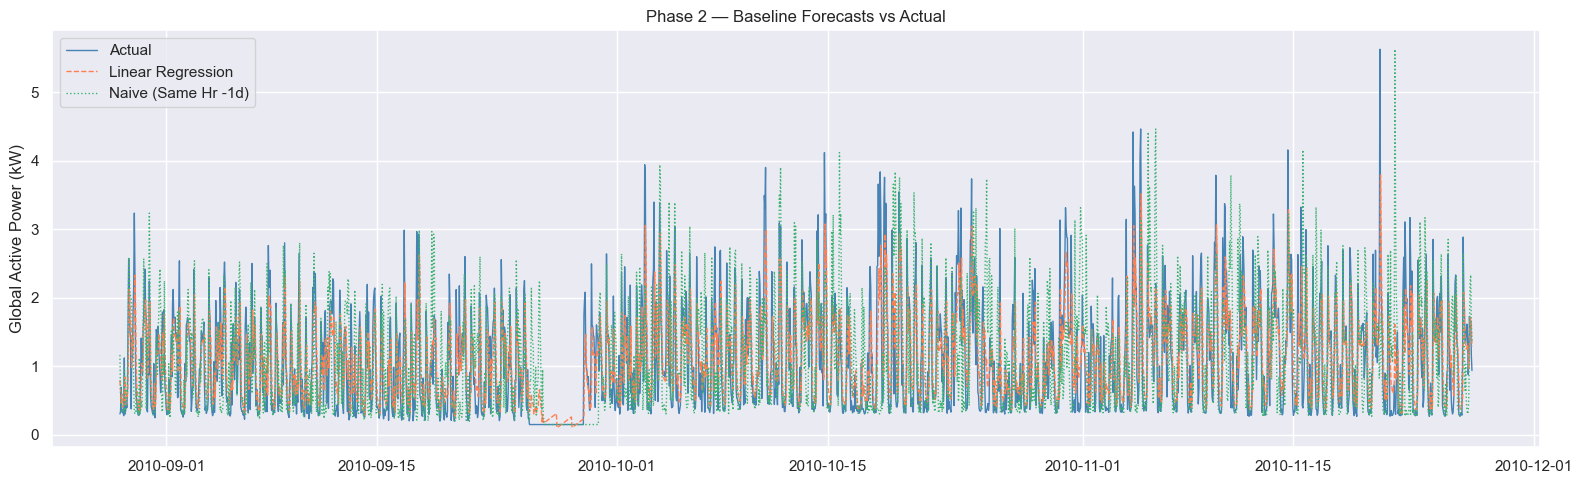

In [83]:
# Plot Linear Regression predictions vs actual
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(y_test.index,  y_test.values,  label='Actual',             color='steelblue',   linewidth=1)
ax.plot(y_test.index,  lr_pred,         label='Linear Regression',  color='coral',       linewidth=1, linestyle='--')
ax.plot(test.index,    lag_24.values,   label='Naive (Same Hr -1d)', color='mediumseagreen', linewidth=1, linestyle=':')

ax.set_title('Phase 2 — Baseline Forecasts vs Actual')
ax.set_ylabel('Global Active Power (kW)')
ax.legend()
plt.tight_layout()
plt.savefig('baseline_vs_actual.png', dpi=150)
plt.show()